In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import clear_output

np.random.seed(13)


In [2]:
grid = np.array([
    [
        ['S', '.', '.'],
        ['.', '.', '.'],
        ['.', '#', '.']
    ],

    [
        ['.', '.', '.'],
        ['.', '.', '.'],
        ['.', '.', '.']
    ],

    [
        ['.', '.', '.'],
        ['.', '.', '.'],
        ['.', '.', 'G']
    ]
])

print(grid.shape)


(3, 3, 3)


In [3]:
floors, rows, cols = grid.shape

start = goal = None
for k in range(floors):
    for i in range(rows):
        for j in range(cols):
            if grid[k][i][j] == 'S':
                start = (k, i, j)
            elif grid[k][i][j] == 'G':
                goal = (k, i, j)

obstacle_start = (1, 1, 1)
MAX_STEPS = 1000
CHASE = 0.5   # how often the obstacle hunts the agent instead of wandering

print("start", start, "goal", goal)


start (0, 0, 0) goal (2, 2, 2)


In [4]:
UP, DOWN, LEFT, RIGHT, ASCEND, DESCEND, WAIT = range(7)
actions = [UP, DOWN, LEFT, RIGHT, ASCEND, DESCEND, WAIT]

moves = {
    UP:      (0, -1,  0),
    DOWN:    (0,  1,  0),
    LEFT:    (0,  0, -1),
    RIGHT:   (0,  0,  1),
    ASCEND:  (1,  0,  0),
    DESCEND: (-1, 0,  0),
    WAIT:    (0,  0,  0),
}


In [5]:
def dist(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1]) + abs(a[2]-b[2])

def reward(agent, obstacle):
    if agent == goal:
        return 100
    if agent == obstacle:
        return -100
    return -1 - 0.01 * dist(agent, goal)

def make_state(agent, obstacle, obstacle_aware):
    return (agent, obstacle) if obstacle_aware else agent

def greedy(Q, agent, obstacle, obstacle_aware=True):
    s = make_state(agent, obstacle, obstacle_aware)
    return max(actions, key=lambda a: Q.get((s, a), 0.0))


In [6]:
def step(state, action):
    f, r, c = state
    df, dr, dc = moves[action]
    nf, nr, nc = f + df, r + dr, c + dc

    if not (0 <= nf < floors and 0 <= nr < rows and 0 <= nc < cols):
        return state
    if grid[nf][nr][nc] == '#':
        return state
    return (nf, nr, nc)

def move_obstacle(obstacle, agent=None, chase=0.0):
    if agent is not None and np.random.rand() < chase:
        best = obstacle
        for a in actions:
            cand = step(obstacle, a)
            if cand != goal and dist(cand, agent) < dist(best, agent):
                best = cand
        return best

    while True:
        cand = step(obstacle, np.random.choice(actions))
        if cand != goal:
            return cand


In [7]:
def train(algo="q", obstacle_aware=True, episodes=10000,
          alpha=0.1, gamma=0.9, eps_min=0.01, chase=CHASE):
    Q = {}
    getq = lambda s, a: Q.get((s, a), 0.0)
    epsilon = 1.0

    def pick(agent, obstacle):
        if np.random.rand() <= epsilon:
            return np.random.choice(actions)
        return greedy(Q, agent, obstacle, obstacle_aware)

    hist = {"steps": [], "crash": [], "epsilon": [], "outcomes": []}

    for ep in range(episodes):
        agent, obstacle = start, obstacle_start
        steps, crashed = 0, False

        while agent != goal and steps < MAX_STEPS:
            if np.random.rand() < 0.3:
                obstacle = move_obstacle(obstacle, agent, chase)
            if agent == obstacle:
                crashed = True
                break

            s = make_state(agent, obstacle, obstacle_aware)
            action = pick(agent, obstacle)
            nxt = step(agent, action)
            r = reward(nxt, obstacle)
            done = nxt == obstacle or nxt == goal
            ns = make_state(nxt, obstacle, obstacle_aware)

            if done:
                target = r
            elif algo == "sarsa":
                target = r + gamma * getq(ns, pick(nxt, obstacle))
            else:
                target = r + gamma * max(getq(ns, a) for a in actions)

            Q[(s, action)] = getq(s, action) + alpha * (target - getq(s, action))
            agent = nxt
            steps += 1
            if done:
                crashed = nxt == obstacle
                break

        hist["steps"].append(steps)
        hist["crash"].append(int(crashed))
        hist["epsilon"].append(epsilon)
        hist["outcomes"].append("goal" if agent == goal else "crash" if crashed else "timeout")
        epsilon = max(eps_min, epsilon * 0.999)


    return Q, hist

Q, hist = train()


training outcomes: {'crash': 3005, 'goal': 6995}
Q range: -99.4 to 100.0


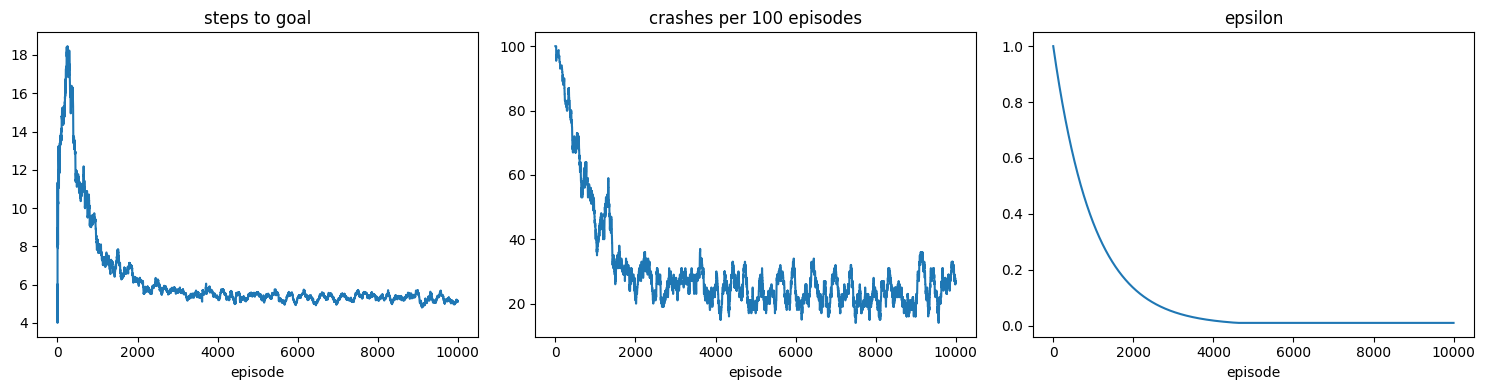

In [8]:
print("training outcomes:", dict(Counter(hist["outcomes"])))
print("Q range:", round(min(Q.values()), 1), "to", round(max(Q.values()), 1))

def moving_avg(x, w=100):
    return [np.mean(x[max(0, i-w+1):i+1]) for i in range(len(x))]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(moving_avg(hist["steps"]))
ax[0].set_title("steps to goal")
ax[0].set_xlabel("episode")

ax[1].plot(np.array(moving_avg(hist["crash"])) * 100)
ax[1].set_title("crashes per 100 episodes")
ax[1].set_xlabel("episode")

ax[2].plot(hist["epsilon"])
ax[2].set_title("epsilon")
ax[2].set_xlabel("episode")

plt.tight_layout()
plt.show()


In [9]:
def evaluate(Q, obstacle_aware=True, n=1000, chase=CHASE):
    out = []
    for _ in range(n):
        agent, obstacle = start, obstacle_start
        steps, result = 0, "timeout"
        while agent != goal and steps < MAX_STEPS:
            if np.random.rand() < 0.3:
                obstacle = move_obstacle(obstacle, agent, chase)
            if agent == obstacle:
                result = "crash"
                break
            agent = step(agent, greedy(Q, agent, obstacle, obstacle_aware))
            steps += 1
            if agent == obstacle:
                result = "crash"
                break
        if agent == goal:
            result = "goal"
        out.append((result, steps))

    counts = Counter(r for r, _ in out)
    goal_steps = [s for r, s in out if r == "goal"]
    avg = np.mean(goal_steps) if goal_steps else float("nan")
    return counts, avg

counts, avg = evaluate(Q)
print("eval:", dict(counts))
print(f"success rate: {counts['goal'] / 1000:.1%}")
print(f"avg steps to goal: {avg:.1f}")


eval: {'goal': 761, 'crash': 239}
success rate: 76.1%
avg steps to goal: 6.1


In [10]:
from matplotlib.lines import Line2D

def render_floors(agent, obstacle, trail=None):
    wall = (grid == '#')
    trail = trail or []

    fig, axes = plt.subplots(1, floors, figsize=(4 * floors, 4))

    for f, ax in enumerate(axes):
        ax.imshow(wall[f], cmap='Greys', vmin=0, vmax=1)
        ax.set_xticks(np.arange(-.5, cols), minor=True)
        ax.set_yticks(np.arange(-.5, rows), minor=True)
        ax.grid(which='minor', color='lightgray')
        ax.set_xticks(range(cols))
        ax.set_yticks(range(rows))
        ax.set_title(f"Floor {f}")

        for tf, tr, tc in trail:
            if tf == f:
                ax.plot(tc, tr, 'o', color='gray', markersize=6, alpha=.4)

        if goal[0] == f:
            ax.plot(goal[2], goal[1], '*', color='gold', markersize=22, markeredgecolor='black')
        if obstacle[0] == f:
            ax.plot(obstacle[2], obstacle[1], 'X', color='red', markersize=16, markeredgecolor='black')
        if agent[0] == f:
            ax.plot(agent[2], agent[1], 'o', color='limegreen', markersize=16, markeredgecolor='black')

    legend = [
        Line2D([], [], marker='*', color='gold', mec='black', ls='', ms=12, label='goal'),
        Line2D([], [], marker='X', color='red', mec='black', ls='', ms=10, label='obstacle'),
        Line2D([], [], marker='o', color='limegreen', mec='black', ls='', ms=10, label='agent'),
    ]
    fig.legend(handles=legend, loc='upper right')
    plt.tight_layout()
    plt.show()


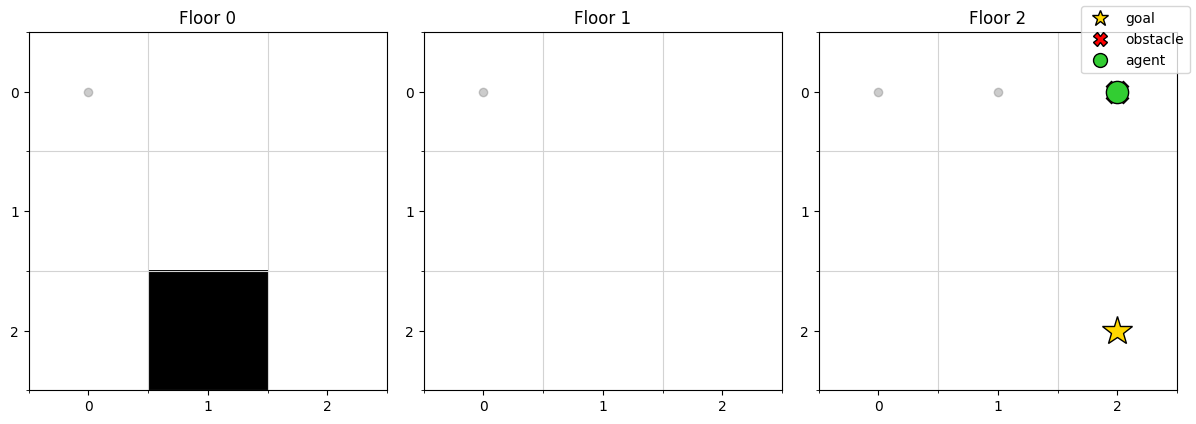

crashed in 4 steps


In [11]:
agent = start
obstacle = obstacle_start

trail = [agent]
step_count = 0
result = "reached goal"

while agent != goal and step_count < MAX_STEPS:

    clear_output(wait=True)
    render_floors(agent, obstacle, trail)

    if np.random.rand() < 0.3:
        obstacle = move_obstacle(obstacle, agent, CHASE)

    if agent == obstacle:
        result = "crashed"
        break

    agent = step(agent, greedy(Q, agent, obstacle))
    trail.append(agent)
    step_count += 1

    time.sleep(0.5)

clear_output(wait=True)
render_floors(agent, obstacle, trail)
print(f"{result} in {step_count} steps")


ablation
obstacle in state: 20.8% ± 4.9
blind to obstacle: 10.5% ± 1.5

q vs sarsa
q-learning: 20.6% ± 4.5
sarsa: 7.1% ± 2.2


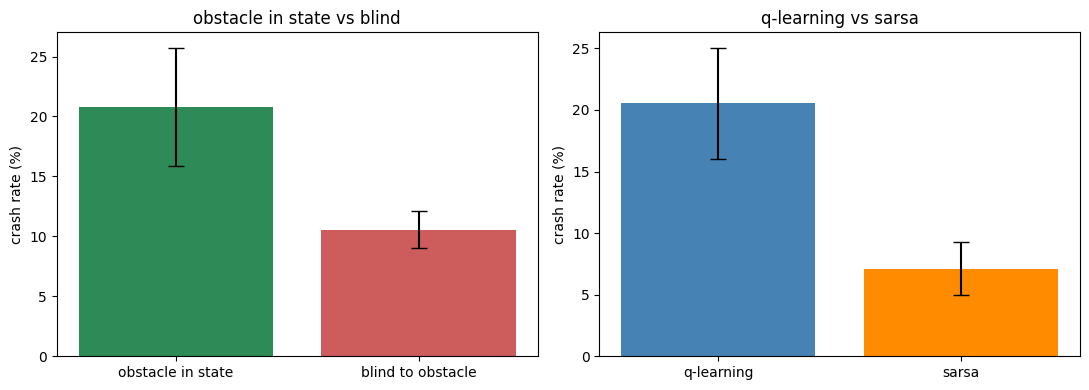

In [12]:
# single-seed bars are noisy, so average each config over a few seeds
# (this retrains a lot of agents - takes a minute or two)
def sweep(configs, seeds=range(8)):
    means, stds = {}, {}
    for name, kw in configs.items():
        aware = kw.get("obstacle_aware", True)
        rates = []
        for s in seeds:
            np.random.seed(s)
            Q, _ = train(**kw)
            counts, _ = evaluate(Q, obstacle_aware=aware)
            rates.append(counts["crash"] / 1000 * 100)
        means[name], stds[name] = np.mean(rates), np.std(rates)
        print(f"{name}: {means[name]:.1f}% ± {stds[name]:.1f}")
    return means, stds

print("ablation")
ablation = sweep({
    "obstacle in state": dict(obstacle_aware=True),
    "blind to obstacle": dict(obstacle_aware=False),
})
print("\nq vs sarsa")
compare = sweep({
    "q-learning": dict(algo="q", eps_min=0.1),
    "sarsa": dict(algo="sarsa", eps_min=0.1),
})

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (means, stds), title, colors in [
    (ax[0], ablation, "obstacle in state vs blind", ["seagreen", "indianred"]),
    (ax[1], compare, "q-learning vs sarsa", ["steelblue", "darkorange"]),
]:
    a.bar(means.keys(), means.values(), yerr=list(stds.values()), capsize=6, color=colors)
    a.set_ylabel("crash rate (%)")
    a.set_title(title)

plt.tight_layout()
plt.show()

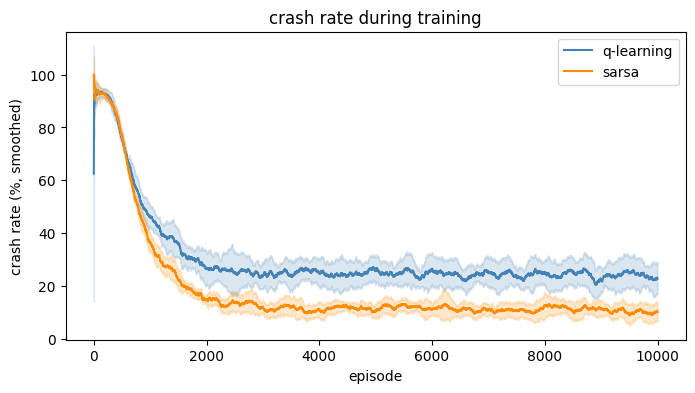

In [13]:
# crash rate over training, averaged across seeds (shaded band = std)
def learning_curves(configs, seeds=range(8), w=200):
    plt.figure(figsize=(8, 4))
    for (name, kw), color in zip(configs.items(), ["steelblue", "darkorange"]):
        curves = []
        for s in seeds:
            np.random.seed(s)
            _, hist = train(**kw)
            curves.append(moving_avg(hist["crash"], w))
        curves = np.array(curves) * 100
        mean, std = curves.mean(0), curves.std(0)
        x = np.arange(len(mean))
        plt.plot(x, mean, color=color, label=name)
        plt.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

    plt.xlabel("episode")
    plt.ylabel("crash rate (%, smoothed)")
    plt.title("crash rate during training")
    plt.legend()
    plt.show()

learning_curves({
    "q-learning": dict(algo="q", eps_min=0.1),
    "sarsa": dict(algo="sarsa", eps_min=0.1),
})